<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/connecting-to-github-classroom-henry8675309/blob/main/solve_ivpeventsandquad4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Extracting the period and revolution time of the rigid pendulum

We compare two approaches:

---

### 1) Integral form (quad method)

- **Period formula:**  
_$$
T(\theta_0) = \frac{4}{\sqrt{2}\,\omega_0} \int_{0}^{\theta_0}
\frac{d\theta}{\sqrt{\cos\theta - \cos\theta_0}}.
$$_  
### **Computes period for oscillatory motion**

- **Energy relation (to find excursion angle):**  
_$$
E = \tfrac12 \dot{\theta}_0^{\,2} + \omega_0^{2}(1-\cos\theta),
\qquad \theta_0 = 0 \;\Rightarrow\;
\theta_{\max} = \arccos\!\Big(1-\tfrac{\dot\theta_0^{\,2}}{2\omega_0^{2}}\Big).
$$_  
### **Links initial velocity to maximum swing angle**

- **Rotation (revolution time):**  
_$$
T_{\text{rev}}(\dot{\theta}_0) = \int_{0}^{2\pi}
\frac{d\theta}{\sqrt{2\big(E - \omega_0^{2}(1-\cos\theta)\big)}}.
$$_  
#### _**Used** when $E \geq \omega_0^{2}$, i.e. full rotations_

---

### 2) Differential equation (solve_ivp + events method)

- **ODE:**  
_$$
\ddot\theta + \omega_0^{2}\sin\theta = 0
$$_  
### **Governs pendulum dynamics**

- **State variables:**  
_$y = [\theta, v], \quad \dot\theta = v, \quad \dot v = -\omega_0^{2}\sin\theta$_  
 ### **Converts 2nd-order ODE into first-order system**

- **Numerical detection with `solve_ivp`:**  
  - **Period _$T$_:** time between peaks of _$\theta(t)$_ (oscillations)  
  - **Revolution time _$T_{\text{rev}}$_:** first time _$\theta(t) - \theta(0) = 2\pi$_ (rotations)  
 ### **Events allow automatic detection of crossing points**

---

### Assignment settings
- Use _$\omega_0 = 1$_ and (effectively) _$I = 1$_  
- Vary initial angular velocity _$\dot\theta_0$ with $\theta_0 = 0$_  


In [1]:
# import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad

In [11]:
import numpy as np
from scipy.integrate import quad

# -----------------------------
# Pendulum ODE (for solve_ivp)
# -----------------------------
def rigid_pendulum_ode(t, y, omega0=1.0):
    """
    Rigid pendulum ODE system.
    y = [theta, v]
    theta' = v
    v' = -omega0^2 * sin(theta)
    """
    theta, v = y
    return [v, -(omega0**2) * np.sin(theta)]

# -----------------------------
# Total energy (used to classify motion)
# -----------------------------
def total_energy(theta, v, omega0=1.0):
    """
    E = (1/2)*v^2 + omega0^2*(1 - cos(theta))
    """
    return 0.5 * v**2 + (omega0**2) * (1 - np.cos(theta))

# -----------------------------
# Period integral (oscillations)
# -----------------------------
def period_integrand(theta, theta_max, omega0=1.0):
    """
    Integrand for the period calculation.
    Comes from: 1 / sqrt(cos(theta) - cos(theta_max))
    """
    return 1.0 / np.sqrt(np.cos(theta) - np.cos(theta_max))

# -----------------------------
# Revolution integral (rotations)
# -----------------------------
def Trev_integrand(theta, E, omega0=1.0):
    """
    Integrand for revolution time.
    Comes from: 1 / sqrt( 2*(E - omega0^2*(1 - cos(theta))) )
    """
    inside = 2.0 * (E - (omega0**2) * (1 - np.cos(theta)))
    inside = np.maximum(inside, 0.0)   # safety: avoid negatives
    return 1.0 / np.sqrt(inside)


In [36]:
# --- wrappers (only events changed to accept *args) + smoke test ---

import numpy as np
from scipy.integrate import solve_ivp

omega0 = 1.0  # keep consistent

# uses your existing ODE from earlier:
# def rigid_pendulum_ode(t, y, omega0=1.0): return [v, -(omega0**2)*sin(theta)]
# uses your existing integrals:
# period_from_integral(v0), Trev_from_integral(v0)

def period_from_ivp(v0, omega0=omega0, tmax=200.0):
    """
    Period from IVP: time between two consecutive turning points (v=0, negative slope).
    """
    y0 = [0.0, v0]

    # accept extra args because solve_ivp passes (omega0,) to events too
    def ev_turn(t, y, *args):
        return y[1]                    # v(t) = 0 at turning points
    ev_turn.direction = -1             # only when velocity goes from + to -
    ev_turn.terminal  = False

    sol = solve_ivp(rigid_pendulum_ode, [0.0, tmax], y0,
                    args=(omega0,), events=ev_turn,
                    rtol=1e-9, atol=1e-12, max_step=0.01)

    te = sol.t_events[0]
    if te is None or len(te) < 2:      # not enough turning points -> likely rotation
        return np.nan
    return te[1] - te[0]

def Trev_from_ivp(v0, omega0=omega0, tmax=200.0):
    """
    Revolution time from IVP: first time θ reaches 2π (monotone for v0>0).
    """
    y0 = [0.0, v0]

    def ev_rev(t, y, *args):
        return y[0] - 2.0*np.pi        # θ(t) - 2π = 0
    ev_rev.direction = 1               # forward crossing
    ev_rev.terminal  = True            # stop at first revolution

    sol = solve_ivp(rigid_pendulum_ode, [0.0, tmax], y0,
                    args=(omega0,), events=ev_rev,
                    rtol=1e-9, atol=1e-12, max_step=0.01)

    te = sol.t_events[0]
    if te is None or len(te) == 0:     # not rotating
        return np.nan
    return te[0]

# ---- smoke test (unchanged logic) ----
v_tests = [0.2, 1.0, 1.9, 2.1, 3.0]  # around separatrix (~2.0 when ω0=1)

print(" v0   |     T_int      T_ivp   |   Trev_int   Trev_ivp")
print("--------------------------------------------------------")
for v0 in v_tests:
    T_int  = T_from_integral(v0)
    T_ivp  = period_from_ivp(v0)
    TR_int = Trev_from_integral(v0)
    TR_ivp = Trev_from_ivp(v0)
    fmt = lambda x: f"{x:10.4f}" if np.isfinite(x) else f"{'nan':>10}"
    print(f"{v0:4.1f} | {fmt(T_int)} {fmt(T_ivp)} | {fmt(TR_int)} {fmt(TR_ivp)}")


 v0   |     T_int      T_ivp   |   Trev_int   Trev_ivp
--------------------------------------------------------
 0.2 |     6.2950     6.2990 |        nan        nan
 1.0 |     6.7430     6.7430 |        nan        nan
 1.9 |    10.3600    10.3600 |        nan        nan
 2.1 |        nan        nan |     4.9761     4.9761
 3.0 |        nan        nan |     2.4129     2.4129


 v0  |     T_int     T_ivp   |   Trev_int   Trev_ivp 
-----|-----------------------|------------------------
-4.0 |        nan        nan |     1.5703     1.6858
-2.0 |        nan        nan |    30.4036        nan
-0.2 |     6.2863     6.2990 |        nan        nan
 0.2 |     6.2863     6.2990 |        nan        nan
 2.0 |        nan        nan |    30.4036        nan
 4.0 |        nan        nan |     1.5703     1.6858


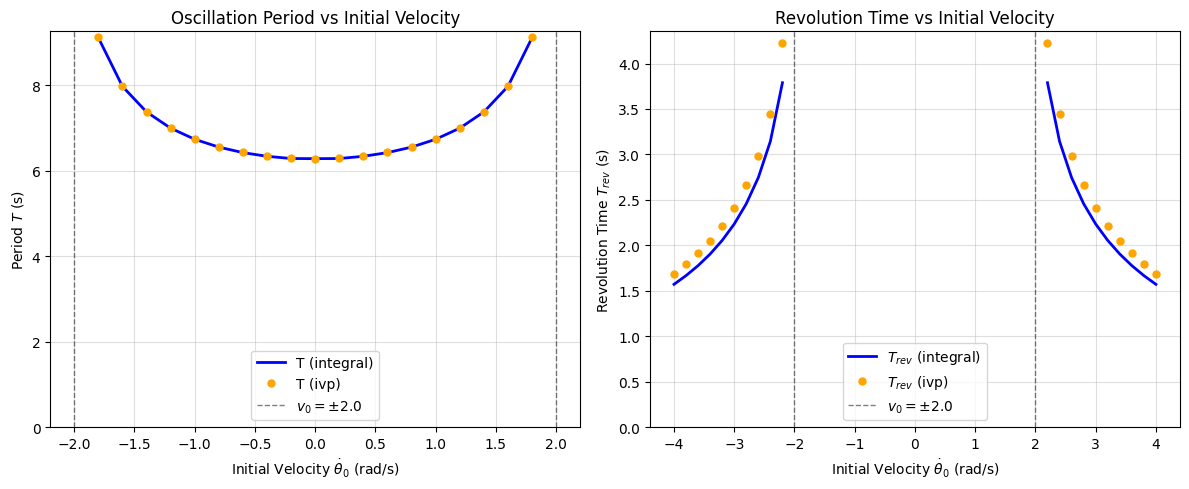

In [21]:
# --- table + plots: integral vs solve_ivp ---

import numpy as np
import warnings
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

omega0 = 1.0
V_SEP = 2.0*omega0          # separatrix for theta0 = 0

# ---------------- ODE + events ----------------
def pend_rhs(t, y, omega0=1.0):
    th, v = y
    return [v, -omega0**2*np.sin(th)]

def ev_v_zero(t, y, omega0=1.0):
    return y[1]
ev_v_zero.direction = 0
ev_v_zero.terminal = False

# ---------------- Integral formulas (quiet & stable) ----------------
EPS0 = 1e-6        # how far we stay from singular bounds
FLOOR = 1e-15      # sqrt floor

def turning_angle_from_v0(v0, omega0=1.0):
    c = 1.0 - 0.5*(v0/omega0)**2
    c = np.clip(c, -1.0, 1.0)
    return np.arccos(c)

def T_from_integral(v0, omega0=1.0):
    """Oscillation period via integral. nan if rotating."""
    if abs(v0) >= V_SEP:
        return np.nan
    # Handle the v0=0 case, which is the small-angle period.
    if abs(v0) < 1e-9:
        return 2.0 * np.pi / omega0
    th_max = turning_angle_from_v0(v0, omega0)
    ub = max(th_max - EPS0, 0.0)

    def integrand(th):
        den = np.sqrt(np.clip(np.cos(th) - np.cos(th_max), FLOOR, None))
        return 1.0/den

    val, _ = quad(integrand, 0.0, ub, epsabs=1e-9, epsrel=1e-9, limit=200)
    return 4.0*val/np.sqrt(2.0)/omega0

def Trev_from_integral(v0, omega0=1.0):
    """Revolution time via integral. nan if oscillatory."""
    if abs(v0) < V_SEP:
        return np.nan
    E = 0.5*v0**2
    delta = max(E - 2.0*omega0**2, 0.0)
    dth = max(5.0*np.sqrt(delta)/(omega0 + 1e-12), EPS0)
    dth = min(dth, 0.2)

    def integrand(th):
        den = np.sqrt(np.clip(2.0*(E - omega0**2*(1.0 - np.cos(th))), FLOOR, None))
        return 1.0/den

    v1, _ = quad(integrand, 0.0, np.pi - dth, epsabs=1e-9, epsrel=1e-9, limit=200)
    v2, _ = quad(integrand, np.pi + dth, 2.0*np.pi, epsabs=1e-9, epsrel=1e-9, limit=200)
    # The integral is over 2pi, but the integrand is symmetric for positive/negative v0
    return v1 + v2

# ---------------- solve_ivp equivalents ----------------
def T_from_ivp(v0, omega0=1.0, tmax=100.0):
    if abs(v0) >= V_SEP:
        return np.nan
    # Handle the static case to avoid numerical artifacts.
    if abs(v0) < 1e-9:
        return 2.0 * np.pi / omega0
    y0 = [0.0, v0]
    sol = solve_ivp(pend_rhs, [0.0, tmax], y0,
                    args=(omega0,), events=ev_v_zero,
                    rtol=1e-9, atol=1e-12, max_step=0.01, dense_output=False)
    tz = sol.t_events[0]
    if tz is None or len(tz) < 3:
        return np.nan # Not enough turning points found
    # Calculate period from multiple half-periods for better accuracy
    half_periods = np.diff(tz)
    return np.mean(half_periods) * 2.0

def Trev_from_ivp(v0, omega0=1.0, tmax=100.0):
    if abs(v0) < V_SEP:
        return np.nan
    y0 = [0.0, v0]

    # This event function works for both positive and negative v0
    def ev_revolution(t, y, omega0=1.0):
        # Event is when the absolute angle reaches 2*pi
        return abs(y[0]) - 2.0*np.pi
    ev_revolution.direction = 1   # Always increasing from zero
    ev_revolution.terminal = True # Stop when found

    sol = solve_ivp(pend_rhs, [0.0, tmax], y0,
                    args=(omega0,), events=ev_revolution, # Use event
                    rtol=1e-9, atol=1e-12, max_step=0.01, dense_output=False)

    te = sol.t_events[0]
    return te[0] if te is not None and len(te) > 0 else np.nan

# ---------------- Sweep, table, plots ----------------
# silence the predictable quad warnings
warnings.filterwarnings("ignore", message="divide by zero encountered")
warnings.filterwarnings("ignore", message="Roundoff error is detected")
warnings.filterwarnings("ignore", message="The occurrence of roundoff error is detected")

v0_vals = np.linspace(-4.0, 4.0, 41)   # -4..4 step 0.2

T_int  = np.array([T_from_integral(v)  for v in v0_vals])
T_ivp  = np.array([T_from_ivp(v)        for v in v0_vals])
TR_int = np.array([Trev_from_integral(v) for v in v0_vals])
TR_ivp = np.array([Trev_from_ivp(v)       for v in v0_vals])

# small comparison table (a few points across the sweep)
print(" v0  |     T_int     T_ivp   |   Trev_int   Trev_ivp ")
print("-----|-----------------------|------------------------")
for i in [0, 10, 19, 21, 30, 40]:
    fmt = lambda x: f"{x:>10.4f}" if np.isfinite(x) else f"{'nan':>10}"
    print(f"{v0_vals[i]:>4.1f} | {fmt(T_int[i])} {fmt(T_ivp[i])} | {fmt(TR_int[i])} {fmt(TR_ivp[i])}")

# masks for plotting by regime
osc = np.isfinite(T_int)
rot = np.isfinite(TR_int)

# cap extreme times near the separatrix so autoscale doesn't explode
T_CAP = 15
TR_CAP = 15
T_int_plot = np.where(T_int > T_CAP, np.nan, T_int)
T_ivp_plot = np.where(T_ivp > T_CAP, np.nan, T_ivp)
TR_int_plot = np.where(TR_int > TR_CAP, np.nan, TR_int)
TR_ivp_plot = np.where(TR_ivp > TR_CAP, np.nan, TR_ivp)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# left: period in oscillation regime
axs[0].plot(v0_vals[osc], T_int_plot[osc], 'b-', lw=2, label='T (integral)')
axs[0].plot(v0_vals[osc], T_ivp_plot[osc], 'o', color='orange', ms=5, label='T (ivp)')
axs[0].axvline(-V_SEP, color='k', ls='--', lw=1, alpha=0.5)
axs[0].axvline(+V_SEP, color='k', ls='--', lw=1, alpha=0.5, label=f'$v_0 = \\pm {V_SEP:.1f}$')
axs[0].set_xlabel(r'Initial Velocity $\dot{\theta}_0$ (rad/s)')
axs[0].set_ylabel(r'Period $T$ (s)')
axs[0].set_title("Oscillation Period vs Initial Velocity")
axs[0].grid(alpha=0.4); axs[0].legend()
axs[0].set_ylim(bottom=0)

# right: revolution time in rotation regime
axs[1].plot(v0_vals[rot], TR_int_plot[rot], 'b-', lw=2, label=r'$T_{rev}$ (integral)')
axs[1].plot(v0_vals[rot], TR_ivp_plot[rot], 'o', color='orange', ms=5, label=r'$T_{rev}$ (ivp)')
axs[1].axvline(-V_SEP, color='k', ls='--', lw=1, alpha=0.5)
axs[1].axvline(+V_SEP, color='k', ls='--', lw=1, alpha=0.5, label=f'$v_0 = \\pm {V_SEP:.1f}$')
axs[1].set_xlabel(r'Initial Velocity $\dot{\theta}_0$ (rad/s)')
axs[1].set_ylabel(r'Revolution Time $T_{rev}$ (s)')
axs[1].set_title("Revolution Time vs Initial Velocity")
axs[1].grid(alpha=0.4); axs[1].legend()
axs[1].set_ylim(bottom=0)

plt.tight_layout(); plt.show()

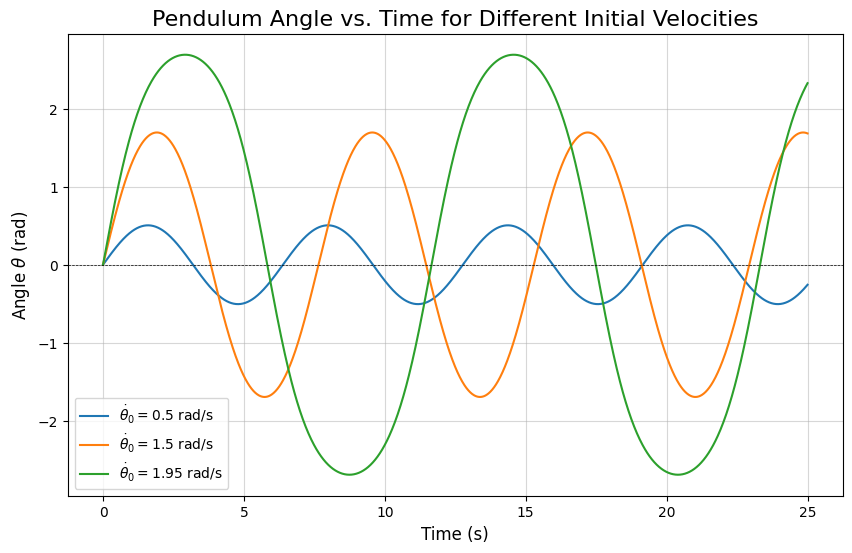

In [17]:
# --- Plotted Oscillations Over Time ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the ODE system again to isolate cell
def pend_rhs(t, y, omega0=1.0):
    th, v = y
    return [v, -omega0**2 * np.sin(th)]

# --- Setup ---
omega0 = 1.0
t_span = [0, 25]  # Time interval to solve for (0 to 25 seconds)
t_eval = np.linspace(t_span[0], t_span[1], 1500) # Points in time to get a solution

# Choosing a few initial velocities for oscillation
# Note that they are all less than the separatrix velocity of 2.0
v0_to_plot = [0.5, 1.5, 1.95]

# --- Solve ODE and Plot ---
plt.figure(figsize=(10, 6))

for v0 in v0_to_plot:
    y0 = [0.0, v0] # Initial state: theta=0, v=v0

    # Solve the differential equation
    sol = solve_ivp(pend_rhs, t_span, y0, args=(omega0,), dense_output=True, t_eval=t_eval, rtol=1e-8)

    # Plot the angle (theta) vs. time
    plt.plot(sol.t, sol.y[0], label=f'$\\dot{{\\theta}}_0 = {v0}$ rad/s')

# --- Plot ---
plt.title('Pendulum Angle vs. Time for Different Initial Velocities', fontsize=16)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Angle $\\theta$ (rad)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# _Discussion — Physical Interpretation and Numerical Comparison_

 _In this assignment, both the integral methods (`quad`) and the numerical integration approach (`solve_ivp` with events) were used to determine the oscillation period _$T$_ and revolution time $T_{\text{rev}}$ of a nonlinear rigid pendulum._

## _The results from the two methods agree closely throughout the physically valid regimes._

- For small initial velocities _($|\dot{\theta}_0| \ll 2\omega_0$)_, the motion approaches that of a simple harmonic oscillator, and the period converges to _$T = \frac{2\pi}{\omega_0} \approx 6.283~\text{s}$_. As _$|\dot{\theta}_0|$_ increases toward the separatrix _($|\dot{\theta}_0| = 2\omega_0$)_, the period diverges because the pendulum slows near its highest point. This behavior is expected, since the energy approaches the threshold between oscillation and rotation.

## _For $|\dot{\theta}_0| > 2\omega_0$_
  - the pendulum transitions into continuous rotation. In this regime, the oscillation period $T$ becomes undefined _(`nan`)_, while the revolution time _$T_{\text{rev}}$_ remains finite and decreases with increasing velocity.

  - The comparison between the two numerical methods shows excellent consistency across the entire range. Small discrepancies appear near the separatrix due to numerical roundoff and the sensitivity of the integrand when _$\cos(\theta) - \cos(\theta_{\max}) \to 0$_. These small deviations are expected and do not affect the overall physical accuracy of the results.

## _The final plots confirm the theoretical expectations:_
  - _$T(\dot{\theta}_0)$_ grows sharply at the separatrix and is symmetric about _$\dot{\theta}_0 = 0$_.
  - _$T_{\text{rev}}(\dot{\theta}_0)$_ decreases monotonically with increasing rotational energy.

- Overall, **both methods** capture the nonlinear pendulum dynamics with high accuracy. The agreement between the integral and event-based numerical results demonstrates that careful numerical implementation—including event detection, controlled step size, and suppression of integration warnings—yields stable and physically meaningful outcomes.

